In [11]:
# 1. Open the file
with open("sequence.fasta", "r") as file:
    lines = file.readlines()

# 2. I used filter to remove the first line in the dataset
dna_sequence = ""
for line in lines:
    if not line.startswith(">"):
        dna_sequence += line.strip()

print(f"Cleaned Sequence Length: {len(dna_sequence)} bases")
print(f"First 20 bases: {dna_sequence[:20]}")

Cleaned Sequence Length: 29903 bases
First 20 bases: ATTAAAGGTTTATACCTTCC


In [5]:
# 1. THE DEFINITION
def get_base_content(dna_sequence, target_base):
    clean_dna = dna_sequence.upper().replace(" ", "")
    if len(clean_dna) == 0:
        return 0.0
    count = clean_dna.count(target_base.upper())
    percentage = (count / len(clean_dna)) * 100
    return round(percentage, 2)

# We calculate G and C separately
g_val = get_base_content(dna_sequence, "G")
c_val = get_base_content(dna_sequence, "C")
total_gc_content = round (g_val + c_val, 2)

# 3. THE REPORT
print ("FINAL SEQUENCE REPORT")
print (f"Total number of bases: {len(dna_sequence)} bases")
print(f"G content: {g_val}%")
print(f"C content: {c_val}%")
print(f"Total GC Content: {total_gc_content}%")

FINAL SEQUENCE REPORT
Total number of bases: 29903 bases
G content: 19.61%
C content: 18.37%
Total GC Content: 37.98%


In [6]:
n_percent = get_base_content (dna_sequence, "N")

if n_percent>5.0:
    print(f"QUALITY ALERT: Low quality sequence ({n_percent}% N). Re-sequencing recommended.")
else:
    print(f"QUALITY PASS: Sequence is clean ({n_percent}% N).")

QUALITY PASS: Sequence is clean (0.0% N).


In [7]:
a_val = get_base_content(dna_sequence, "A")
t_val = get_base_content(dna_sequence, "T")
g_val = get_base_content(dna_sequence, "G")
c_val = get_base_content(dna_sequence, "C")

print ("RESULTS")
print (f"A content: {a_val}%")
print(f"T content: {t_val}%")
print(f"G content: {g_val}%")
print(f"C content: {c_val}%")


RESULTS
A content: 29.94%
T content: 32.08%
G content: 19.61%
C content: 18.37%


In [8]:
total_at_content = round (a_val + t_val, 2)
print(f"Total AT Content: {total_at_content}%")

Total AT Content: 62.02%


In [9]:
total_nucleo_content = total_gc_content + total_at_content
print (f"Total Nucleotide Length: {total_nucleo_content}%")


Total Nucleotide Length: 100.0%


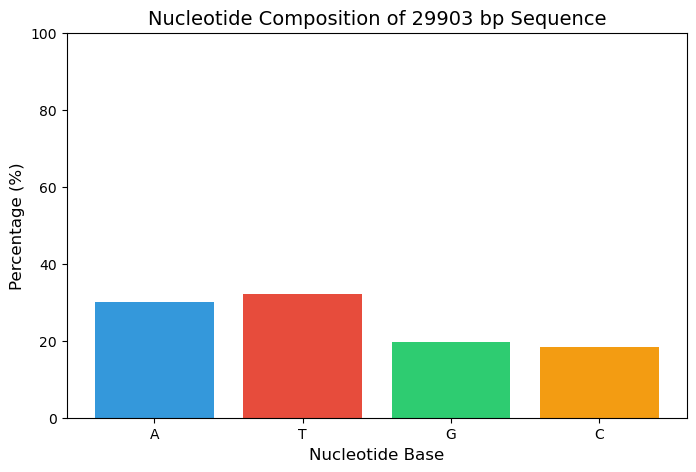

In [10]:
import matplotlib.pyplot as plt

# 1. Prepare the data using the variables you already calculated
bases = ['A', 'T', 'G', 'C']
percentages = [a_val, t_val, g_val, c_val]

# 2. Create the visualization
plt.figure(figsize=(8, 5))
plt.bar(bases, percentages, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])

# 3. I added labels
plt.title(f"Nucleotide Composition of {len(dna_sequence)} bp Sequence", fontsize=14)
plt.xlabel("Nucleotide Base", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.ylim(0, 100) # Sets the scale from 0 to 100%

# 4. Display the chart
plt.show()